# Title + Objective (Markdown)

# Imbalance Handling — EcoType Forest Cover Classification

## Objective
- detect class imbalance severity
- test imbalance-handling strategies without leakage
- compare baseline vs imbalance-aware pipelines
- select the best strategy to carry forward into tuning

# Imports + Global Config (Code)

In [7]:
from pathlib import Path

import numpy as np
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import cross_validate

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import cross_validate, StratifiedKFold
from src.modeling.imbalance import build_imbalanced_pipeline

SEED = 42
PRIMARY_METRIC = "f1_macro"

DATA_DIR = Path("../data/processed")
REPORT_DIR = Path("../reports/model_results")
FIG_DIR = Path("../reports/figures")

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Helper Functions

In [20]:
def evaluate_pipeline(name, pipeline, X_train, y_train, X_test, y_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    per_class_recall = recall_score(y_test, y_pred, average=None, zero_division=0)
    minority_class = y_train.value_counts().idxmin()
    minority_recall = recall_score(
        y_test == minority_class,
        y_pred == minority_class,
        zero_division=0,
    )

    results = {
        "strategy": name,
        "accuracy_test": accuracy_score(y_test, y_pred),
        "f1_macro_test": f1_score(y_test, y_pred, average="macro"),
        "minority_class": minority_class,
        "minority_class_recall": minority_recall,
        "per_class_recall": per_class_recall,
        "y_pred": y_pred,
        "pipeline": pipeline,
    }
    return results


def run_cv(name, pipeline, X_train, y_train, cv):
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=PRIMARY_METRIC,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise"
    )
    return {
        "strategy": name,
        "cv_f1_macro_mean": scores["test_score"].mean(),
        "cv_f1_macro_std": scores["test_score"].std(),
    }


def save_report(path, y_true, y_pred):
    report_text = classification_report(y_true, y_pred, zero_division=0)
    with open(path, "w", encoding="utf-8") as f:
        f.write(report_text)


def save_cm(path, y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, cmap="Blues")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

# Load Train/Test Splits (Code)

In [3]:
X_train = pd.read_csv(DATA_DIR / "X_train.csv")
X_test = pd.read_csv(DATA_DIR / "X_test.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze("columns")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print("Target dtype:", y_train.dtype)

assert len(X_train) == len(y_train), "Mismatch between X_train and y_train"
assert len(X_test) == len(y_test), "Mismatch between X_test and y_test"

X_train: (116712, 20)
X_test : (29178, 20)
y_train: (116712,)
y_test : (29178,)
Target dtype: object


In [8]:
from pathlib import Path

path = Path("../models/preprocessing_pipeline.joblib")

print("Exists:", path.exists())
if path.exists():
    print("Size in bytes:", path.stat().st_size)

Exists: True
Size in bytes: 0


In [9]:
preprocessor = joblib.load("../models/preprocessing_pipeline.joblib")
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.0
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

# Check Imbalance Severity (Code)

In [10]:
class_counts = y_train.value_counts().sort_index()
class_pct = y_train.value_counts(normalize=True).sort_index() * 100

max_class = class_counts.idxmax()
min_class = class_counts.idxmin()
imbalance_ratio = class_counts.max() / class_counts.min()

print("Class counts:\n", class_counts, "\n")
print("Class percentages (%):\n", class_pct.round(2), "\n")
print(f"Majority class : {max_class}")
print(f"Minority class : {min_class}")
print(f"Imbalance ratio: {imbalance_ratio:.2f}")

if imbalance_ratio < 1.5:
    severity = "mild"
elif imbalance_ratio < 3:
    severity = "moderate"
else:
    severity = "severe"

print(f"\nImbalance severity: {severity}")
print("Rule used: <1.5 = mild, 1.5–3 = moderate, >3 = severe")

Class counts:
 cover_type
Aspen                 2455
Cottonwood/Willow     1728
Douglas-fir           1728
Krummholz             1728
Lodgepole Pine       82457
Ponderosa Pine        1728
Spruce/Fir           24888
Name: count, dtype: int64 

Class percentages (%):
 cover_type
Aspen                 2.10
Cottonwood/Willow     1.48
Douglas-fir           1.48
Krummholz             1.48
Lodgepole Pine       70.65
Ponderosa Pine        1.48
Spruce/Fir           21.32
Name: proportion, dtype: float64 

Majority class : Lodgepole Pine
Minority class : Cottonwood/Willow
Imbalance ratio: 47.72

Imbalance severity: severe
Rule used: <1.5 = mild, 1.5–3 = moderate, >3 = severe


# Plot Class Distribution (Code)

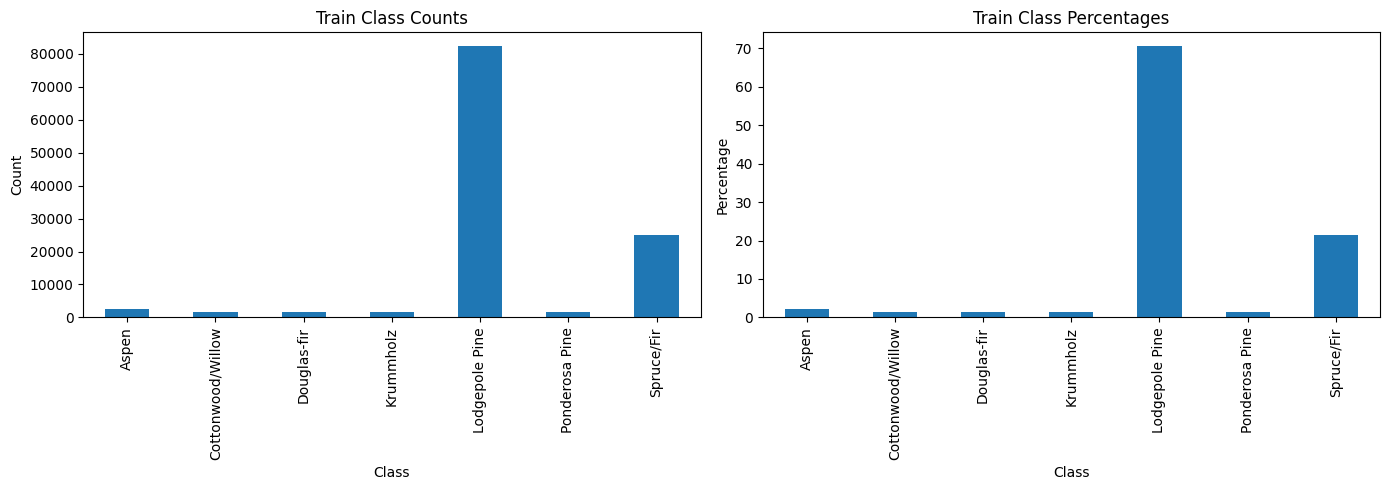

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Train Class Counts")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

class_pct.plot(kind="bar", ax=axes[1])
axes[1].set_title("Train Class Percentages")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Percentage")

plt.tight_layout()
plt.savefig(FIG_DIR / "class_imbalance_train.png", dpi=300, bbox_inches="tight")
plt.show()

# Baseline Model Without Any Imbalance Fix (Code)

In [14]:
base_model = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED,
    n_jobs=-1,
)

baseline_pipeline = build_imbalanced_pipeline(
    preprocessor=preprocessor,
    estimator=base_model,
    strategy="none",
    random_state=SEED,
)

results_baseline = evaluate_pipeline(
    "baseline", baseline_pipeline, X_train, y_train, X_test, y_test
)

results_baseline

{'strategy': 'baseline',
 'accuracy_test': 0.9592158475563781,
 'f1_macro_test': 0.914571441166691,
 'minority_class': 'Cottonwood/Willow',
 'minority_class_recall': 0.9583333333333334,
 'per_class_recall': array([0.86970684, 0.95833333, 0.875     , 0.96759259, 0.9846221 ,
        0.85185185, 0.89665702]),
 'y_pred': array(['Spruce/Fir', 'Lodgepole Pine', 'Lodgepole Pine', ...,
        'Lodgepole Pine', 'Spruce/Fir', 'Lodgepole Pine'],
       shape=(29178,), dtype=object),
 'pipeline': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(sparse_threshold=0.0,
                                    transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median'))]),
                                                   ['elevation', 'aspect',
                                                    'vertical_distance_to_hydrology',
               

# Baseline Confusion Matrix + Report (Code)

                   precision    recall  f1-score   support

            Aspen       0.91      0.87      0.89       614
Cottonwood/Willow       0.95      0.96      0.95       432
      Douglas-fir       0.84      0.88      0.86       432
        Krummholz       0.94      0.97      0.95       432
   Lodgepole Pine       0.97      0.98      0.98     20614
   Ponderosa Pine       0.85      0.85      0.85       432
       Spruce/Fir       0.95      0.90      0.92      6222

         accuracy                           0.96     29178
        macro avg       0.91      0.91      0.91     29178
     weighted avg       0.96      0.96      0.96     29178



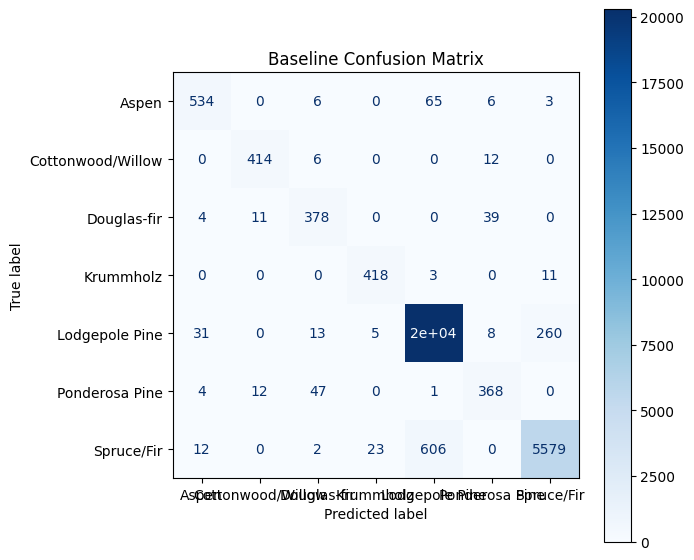

In [15]:
print(classification_report(y_test, results_baseline["y_pred"], zero_division=0))

save_report(
    REPORT_DIR / "imbalance_baseline_report.txt",
    y_test,
    results_baseline["y_pred"],
)

save_cm(
    REPORT_DIR / "imbalance_baseline_cm.png",
    y_test,
    results_baseline["y_pred"],
    "Baseline Confusion Matrix",
)

# Strategy 1: class_weight="balanced" (Code)

In [16]:
classweight_pipeline = build_imbalanced_pipeline(
    preprocessor=preprocessor,
    estimator=base_model,
    strategy="class_weight",
    class_weight="balanced",
    random_state=SEED,
)

results_classweight = evaluate_pipeline(
    "class_weight", classweight_pipeline, X_train, y_train, X_test, y_test
)

results_classweight

{'strategy': 'class_weight',
 'accuracy_test': 0.9591815751593666,
 'f1_macro_test': 0.9122036527412868,
 'minority_class': 'Cottonwood/Willow',
 'minority_class_recall': 0.9583333333333334,
 'per_class_recall': array([0.8713355 , 0.95833333, 0.875     , 0.96064815, 0.98549529,
        0.83333333, 0.89521054]),
 'y_pred': array(['Spruce/Fir', 'Lodgepole Pine', 'Lodgepole Pine', ...,
        'Lodgepole Pine', 'Spruce/Fir', 'Lodgepole Pine'],
       shape=(29178,), dtype=object),
 'pipeline': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(sparse_threshold=0.0,
                                    transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median'))]),
                                                   ['elevation', 'aspect',
                                                    'vertical_distance_to_hydrology',
          

# Strategy 2: Random OverSampling (Code)

In [27]:
ros_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("oversampler", RandomOverSampler(random_state=SEED)),
        ("model", RandomForestClassifier(
            n_estimators = 50,
            max_depth = 15,
            random_state = SEED,
            n_jobs = -1,
        )),
    ]
)

results_ros = evaluate_pipeline(
    "random_oversampling", ros_pipeline, X_train, y_train, X_test, y_test
)

results_ros

{'strategy': 'random_oversampling',
 'accuracy_test': 0.9156899033518404,
 'f1_macro_test': 0.8791856928060111,
 'minority_class': 'Cottonwood/Willow',
 'minority_class_recall': 0.9351851851851852,
 'per_class_recall': array([0.94136808, 0.93518519, 0.89583333, 0.97685185, 0.91680411,
        0.81018519, 0.91256831]),
 'y_pred': array(['Spruce/Fir', 'Lodgepole Pine', 'Lodgepole Pine', ...,
        'Lodgepole Pine', 'Spruce/Fir', 'Lodgepole Pine'],
       shape=(29178,), dtype=object),
 'pipeline': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(sparse_threshold=0.0,
                                    transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median'))]),
                                                   ['elevation', 'aspect',
                                                    'vertical_distance_to_hydrology',
   

# Strategy 3: SMOTE (Code)

In [18]:
smote_pipeline = build_imbalanced_pipeline(
    preprocessor=preprocessor,
    estimator=base_model,
    strategy="smote",
    smote_k_neighbors=5,
    random_state=SEED,
)

results_smote = evaluate_pipeline(
    "SMOTE", smote_pipeline, X_train, y_train, X_test, y_test
)

results_smote

{'strategy': 'SMOTE',
 'accuracy_test': 0.9598670230995956,
 'f1_macro_test': 0.9157863242862742,
 'minority_class': 'Cottonwood/Willow',
 'minority_class_recall': 0.9675925925925926,
 'per_class_recall': array([0.94462541, 0.96759259, 0.87731481, 0.98842593, 0.96997186,
        0.8587963 , 0.93812279]),
 'y_pred': array(['Spruce/Fir', 'Lodgepole Pine', 'Lodgepole Pine', ...,
        'Lodgepole Pine', 'Spruce/Fir', 'Lodgepole Pine'],
       shape=(29178,), dtype=object),
 'pipeline': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(sparse_threshold=0.0,
                                    transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median'))]),
                                                   ['elevation', 'aspect',
                                                    'vertical_distance_to_hydrology',
                 

# Leakage Control Cell

## Leakage Control Checklist

- SMOTE / oversampling must happen only on training data
- Never apply SMOTE on the full dataset before train-test split
- During cross-validation, resampling must be inside the pipeline
- The CV splitter should operate on the original training set only
- The test set must remain untouched until final evaluation

# CV-based Comparison (No Leakage) (Code)

In [23]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED,
)

cv_baseline = run_cv("baseline", baseline_pipeline, X_train, y_train, cv)


In [24]:
cv_classweight = run_cv("class_weight", classweight_pipeline, X_train, y_train, cv)

In [25]:
cv_smote = run_cv("SMOTE", smote_pipeline, X_train, y_train, cv)

In [28]:
cv_ros = run_cv("random_oversampling", ros_pipeline, X_train, y_train, cv)

# Compare Strategies Table (Code)

In [29]:
comparison_df = pd.DataFrame([
    {
        "strategy": results_baseline["strategy"],
        "accuracy_test": results_baseline["accuracy_test"],
        "f1_macro_test": results_baseline["f1_macro_test"],
        "minority_class_recall": results_baseline["minority_class_recall"],
        "notes": "No imbalance handling",
    },
    {
        "strategy": results_classweight["strategy"],
        "accuracy_test": results_classweight["accuracy_test"],
        "f1_macro_test": results_classweight["f1_macro_test"],
        "minority_class_recall": results_classweight["minority_class_recall"],
        "notes": "Uses class_weight='balanced'",
    },
    {
        "strategy": results_ros["strategy"],
        "accuracy_test": results_ros["accuracy_test"],
        "f1_macro_test": results_ros["f1_macro_test"],
        "minority_class_recall": results_ros["minority_class_recall"],
        "notes": "Random over-sampling inside pipeline",
    },
    {
        "strategy": results_smote["strategy"],
        "accuracy_test": results_smote["accuracy_test"],
        "f1_macro_test": results_smote["f1_macro_test"],
        "minority_class_recall": results_smote["minority_class_recall"],
        "notes": "SMOTE inside pipeline",
    },
])

cv_df = pd.DataFrame([cv_baseline, cv_classweight, cv_ros, cv_smote])

comparison_df = comparison_df.merge(cv_df, on="strategy", how="left")
comparison_df = comparison_df.sort_values(
    by=["f1_macro_test", "minority_class_recall"],
    ascending=[False, False],
).reset_index(drop=True)

comparison_df

,strategy,accuracy_test,f1_macro_test,minority_class_recall,notes,cv_f1_macro_mean,cv_f1_macro_std
0,SMOTE,0.959867,0.915786,0.967593,SMOTE inside pipeline,0.893581,0.003345
1,baseline,0.959216,0.914571,0.958333,No imbalance handling,0.894687,0.004351
2,class_weight,0.959182,0.912204,0.958333,Uses class_weight='balanced',0.895178,0.004058
3,random_oversampling,0.915690,0.879186,0.935185,Random over-sampling inside pipeline,0.872232,0.002174


In [30]:
comparison_df.to_csv(
    REPORT_DIR / "imbalance_strategy_comparison.csv",
    index=False,
)

# Confusion Matrices for Best 2 Strategies (Code)

Select best 2 based on table

Plot confusion matrices side-by-side (or separately)

Save:

reports/model_results/imbalance_best1_cm.png

reports/model_results/imbalance_best2_cm.png

In [31]:
result_map = {
    "baseline": results_baseline,
    "class_weight": results_classweight,
    "random_oversampling": results_ros,
    "SMOTE": results_smote,
}

best_2 = comparison_df["strategy"].head(2).tolist()
best_2

['SMOTE', 'baseline']

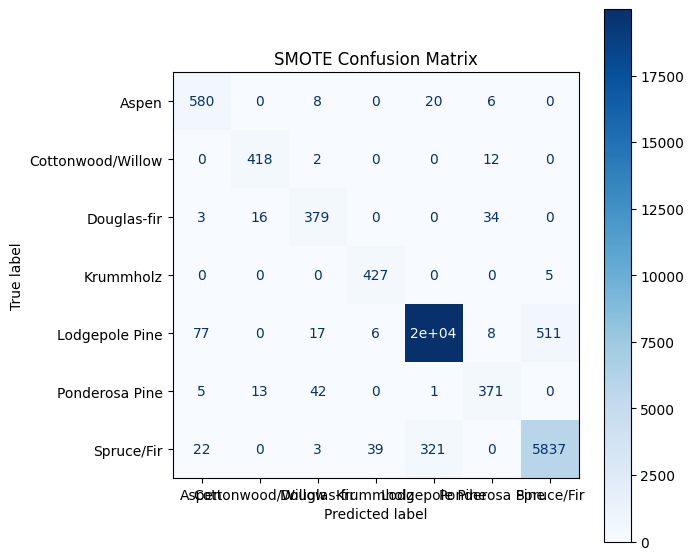

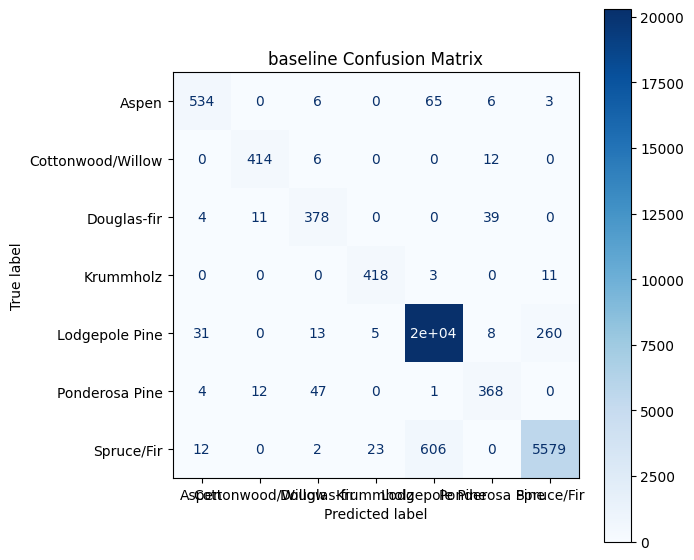

In [32]:
for i, strategy_name in enumerate(best_2, start=1):
    save_cm(
        REPORT_DIR / f"imbalance_best{i}_cm.png",
        y_test,
        result_map[strategy_name]["y_pred"],
        f"{strategy_name} Confusion Matrix",
    )

# Final Decision Cell (Markdown)

## Final Decision

### Chosen strategy
- _Fill after reviewing comparison table_

### Why this strategy was selected
- strongest macro F1 on test set
- good minority-class recall
- stable cross-validation performance
- no leakage risk because resampling stayed inside pipeline
- acceptable runtime and implementation complexity

### Model to carry into tuning
- RandomForestClassifier

### Constraints / notes
- oversampling methods may increase runtime
- class_weight is simpler and often more stable
- SMOTE may help minority classes but should be validated with CV

# Save Artifacts / Export Notes (Code)

In [33]:
best_strategy = comparison_df.iloc[0]["strategy"]

decision_md = f"""# Imbalance Handling Decision

## Selected Strategy
**{best_strategy}**

## Reason
- Selected based on highest macro F1 on test set
- Tie-breaker considered minority class recall
- Cross-validation macro F1 was reviewed for stability
- Leakage was avoided by keeping resampling inside the pipeline

## Model for Tuning
- RandomForestClassifier

## Constraints
- Oversampling increases runtime
- Class-weight approach is simpler
- Final choice should balance performance and stability
"""

with open(REPORT_DIR / "imbalance_decision.md", "w", encoding="utf-8") as f:
    f.write(decision_md)

print("Saved decision notes.")

Saved decision notes.
